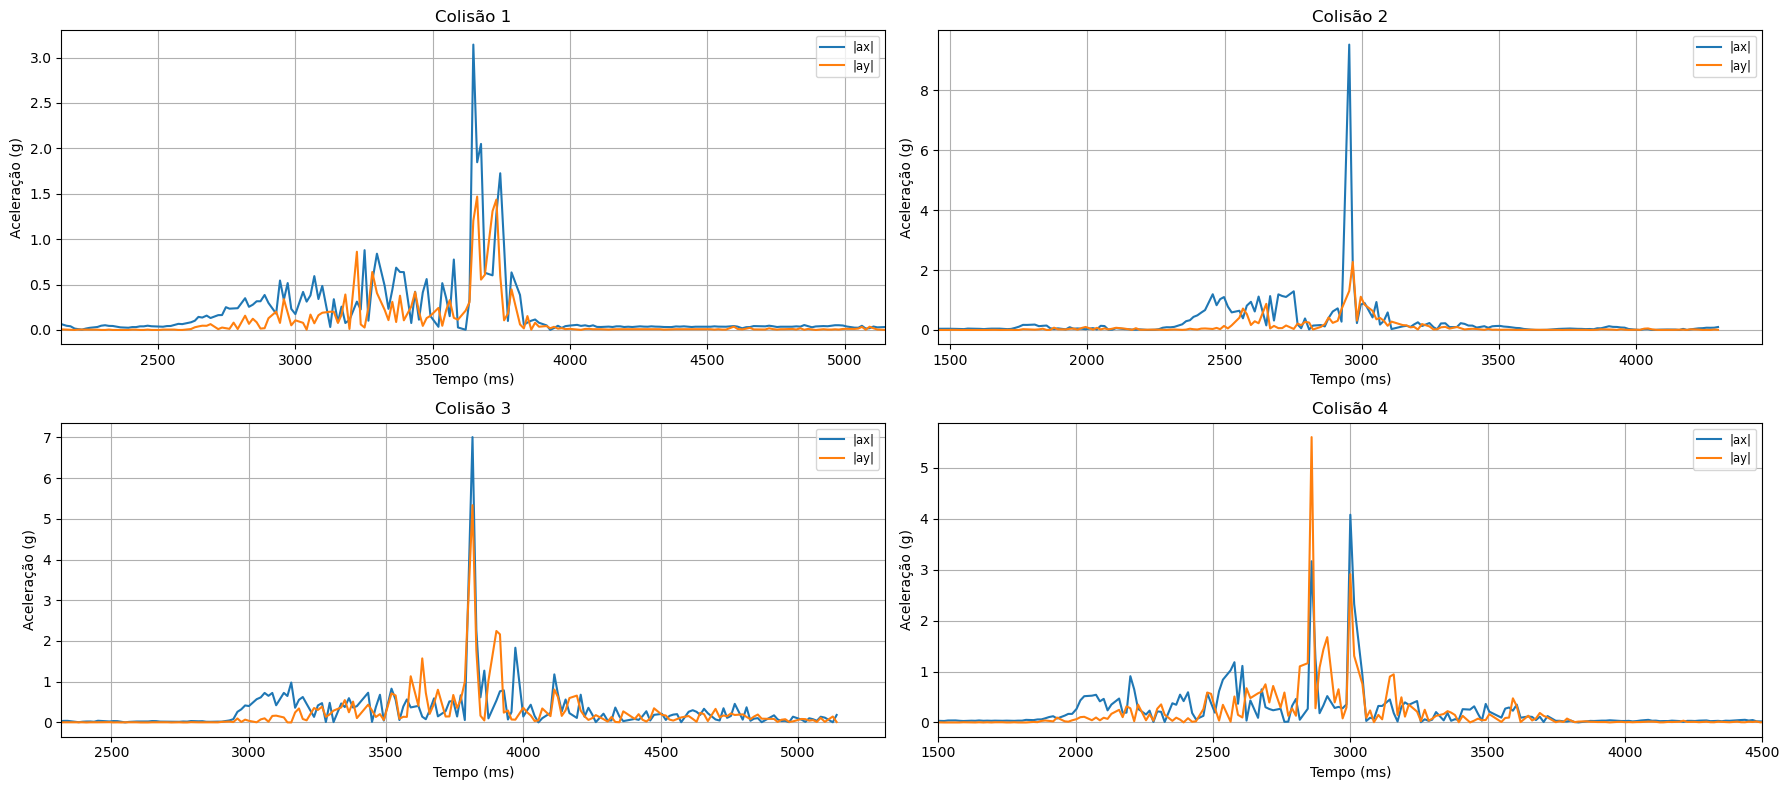

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import math
g = 9.81
# Load the data
file_path = r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\colisoes_lab.txt"
ax, ay, az, roll, pitch, col, time = np.loadtxt(file_path, unpack=True)

# Combine into one array: [time, ax, ay, roll, pitch, col]
data = np.column_stack((time, ax, ay, roll, pitch, col))

# Find breakpoints where time resets
breaks = [0]
for i in range(1, len(time)):
    if time[i] < time[i - 1]:
        breaks.append(i)
breaks.append(len(time))

# Filter segments where either ax or ay exceed |3000|
valid_segments = []
for seg_num in range(len(breaks) - 1):
    start, end = breaks[seg_num], breaks[seg_num + 1]
    segment = data[start:end]
    ax_seg = segment[:, 1]
    ay_seg = segment[:, 2]
    
    if np.max(np.abs(ax_seg)) >= 3000 or np.max(np.abs(ay_seg)) >= 3000:
        valid_segments.append((start, end))

# Prepare subplots
num_valid = len(valid_segments)
cols = 2
rows = math.ceil(num_valid / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows), squeeze=False)

# Plot each valid segment
for idx, (start, end) in enumerate(valid_segments):
    segment = data[start:end]

    t = segment[:, 0]
    ax_seg = segment[:, 1]
    ay_seg = segment[:, 2]
    roll_seg = segment[:, 3]
    pitch_seg = segment[:, 4]
    col_seg = segment[:, 5]

    row, col_idx = divmod(idx, cols)
    ax_subplot = axes[row][col_idx]
    
    ax_subplot.plot(t, np.abs(ax_seg/(100*g)), label='|ax|')
    ax_subplot.plot(t, np.abs(ay_seg/(100*g)), label='|ay|')
    #ax_subplot.plot(t, np.sqrt(ax_seg**2 + ay_seg**2), label = 'a')
    #ax_subplot.plot(t, roll_seg, label='roll')
    #ax_subplot.plot(t, pitch_seg, label='pitch')
    #ax_subplot.plot(t, col_seg, label='col')

    ax_subplot.set_title(f'Colisão {idx + 1}')
    ax_subplot.set_xlabel('Tempo (ms)')
    ax_subplot.set_ylabel('Aceleração (g)')
    ax_subplot.grid(True)
    ax_subplot.legend(fontsize='small')
    ax_subplot.set_xlim(time[np.argmin(ax_seg)] - 1500, time[np.argmin(ax_seg)] + 1500)

# Hide unused subplots
for i in range(num_valid, rows * cols):
    row, col_idx = divmod(i, cols)
    fig.delaxes(axes[row][col_idx])

plt.tight_layout()
plt.show()


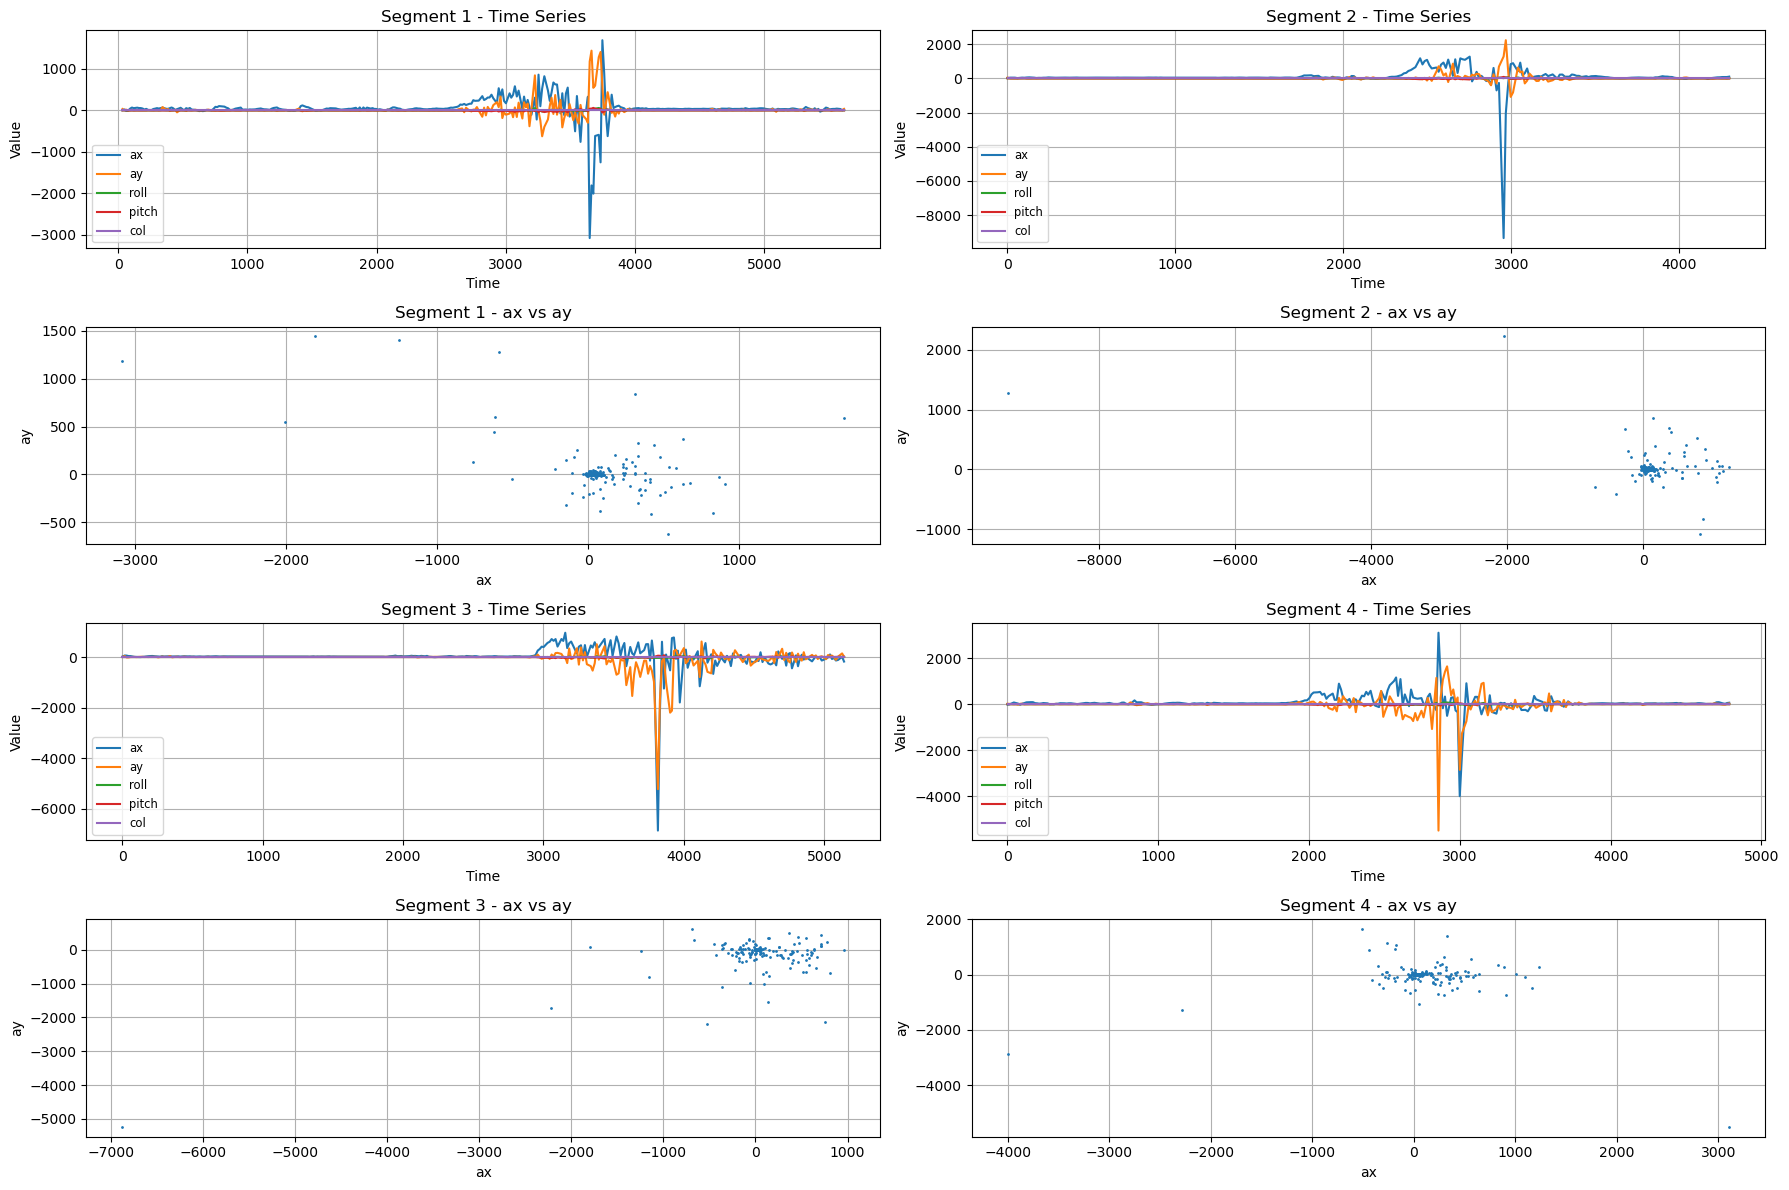

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Load the data
file_path = r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\colisoes_lab.txt"
ax, ay, az, roll, pitch, col, time = np.loadtxt(file_path, unpack=True)

# Combine into one array: [time, ax, ay, roll, pitch, col]
data = np.column_stack((time, ax, ay, roll, pitch, col))

# Find breakpoints where time resets
breaks = [0]
for i in range(1, len(time)):
    if time[i] < time[i - 1]:
        breaks.append(i)
breaks.append(len(time))

# Filter segments where either ax or ay exceed |3000|
valid_segments = []
for seg_num in range(len(breaks) - 1):
    start, end = breaks[seg_num], breaks[seg_num + 1]
    segment = data[start:end]
    ax_seg = segment[:, 1]
    ay_seg = segment[:, 2]
    
    if np.max(np.abs(ax_seg)) >= 3000 or np.max(np.abs(ay_seg)) >= 3000:
        valid_segments.append((start, end))

# Plot layout
num_valid = len(valid_segments)
cols = 2
rows = math.ceil(num_valid / cols)

fig, axes = plt.subplots(rows * 2, cols, figsize=(18, 6 * rows), squeeze=False)

# Plot each valid segment
for idx, (start, end) in enumerate(valid_segments):
    segment = data[start:end]

    t = segment[:, 0]
    ax_seg = segment[:, 1]
    ay_seg = segment[:, 2]
    roll_seg = segment[:, 3]
    pitch_seg = segment[:, 4]
    col_seg = segment[:, 5]

    row_ts, col_ts = divmod(idx, cols)
    row_ts *= 2  # Make space for second row (ax vs ay)

    # --- Time series plot ---
    ax_ts = axes[row_ts][col_ts]
    ax_ts.plot(t, ax_seg, label='ax')
    ax_ts.plot(t, ay_seg, label='ay')
    ax_ts.plot(t, roll_seg, label='roll')
    ax_ts.plot(t, pitch_seg, label='pitch')
    ax_ts.plot(t, col_seg, label='col')

    ax_ts.set_title(f'Segment {idx + 1} - Time Series')
    ax_ts.set_xlabel('Time')
    ax_ts.set_ylabel('Value')
    ax_ts.grid(True)
    ax_ts.legend(fontsize='small')

    # --- ax vs ay plot ---
    ax_scatter = axes[row_ts + 1][col_ts]
    ax_scatter.plot(ax_seg, ay_seg, '.', markersize=2)
    ax_scatter.set_title(f'Segment {idx + 1} - ax vs ay')
    ax_scatter.set_xlabel('ax')
    ax_scatter.set_ylabel('ay')
    ax_scatter.grid(True)

# Hide any unused subplots
for i in range(num_valid, rows * cols):
    row, col_idx = divmod(i, cols)
    fig.delaxes(axes[row * 2][col_idx])
    fig.delaxes(axes[row * 2 + 1][col_idx])

plt.tight_layout()
plt.show()

